In [1]:
import pandas as pd

import matplotlib.pyplot as plt

## Info

In [2]:
df = pd.read_excel("./data/air_data/info batch date and time.xlsx").dropna(how = "all")
df.sort_values(by = "batch")
df["start_date"] = df["Date online extraction"].apply(lambda x: pd.to_datetime(x.split()[0], dayfirst = True))
df["end_date"] = df["Date online extraction"].apply(lambda x: pd.to_datetime(x.split()[-1], dayfirst = True))
df["date_diff"] = df["end_date"] - df["start_date"]
df.drop("Date online extraction", axis = 1, inplace = True)
df.to_csv("./processed/batch_info.csv", index = None)
batch_info = df.copy()

In [3]:
samples = pd.read_excel("./data/air_data/info batch date and time.xlsx", sheet_name = 1)
samples.columns = [f"Col {i+1}" for i in range(len(samples.columns))]

for idx in [16, 19, 22, 25]:
    samples[f"Col {idx+1}"] = pd.to_datetime(samples[f"Col {idx}"].apply(lambda x: str(x).split()[0]) + " " + samples[f"Col {idx+1}"].astype(str))
    del samples[f"Col {idx}"]
samples.columns = [f"Col {i+1}" for i in range(len(samples.columns))]

new_sampling = []
for i in range(11):
    columns = samples.columns[(i * 2) : (i * 2) + 2]
    batch = samples[columns[0]].iloc[0]
    values = samples[columns[1]].tolist()
    new_sampling.append([batch] + values)
new_sampling = pd.DataFrame(new_sampling, columns = ["Batch"] + [f"Sampling - Day {i}" for i in range(15)])
new_sampling.to_csv("./processed/sampling_times.csv", index = None)

## Data

In [4]:
df = pd.read_excel("./data/air_data/FI468-air overlay.xlsx")
df

,db,start,end,tag,point,timestamp,value
0,DB0440,2025-11-17,2025-12-03 23:59:59,FI468_value,DB0440_FI468_value,2025-11-17 00:00:00.0000000,40.078125
1,DB0440,2025-11-17,2025-12-03 23:59:59,FI468_value,DB0440_FI468_value,2025-11-17 00:00:19.6039886,40.081249
2,DB0440,2025-11-17,2025-12-03 23:59:59,FI468_value,DB0440_FI468_value,2025-11-17 00:00:20.6005401,40.078125
3,DB0440,2025-11-17,2025-12-03 23:59:59,FI468_value,DB0440_FI468_value,2025-11-17 00:01:13.7856445,40.078125
4,DB0440,2025-11-17,2025-12-03 23:59:59,FI468_value,DB0440_FI468_value,2025-11-17 00:01:14.7856445,40.093750
...,...,...,...,...,...,...,...
591446,DB0460,2026-02-09,2026-02-24 23:59:59,FI468_value,DB0460_FI468_value,2026-02-24 23:54:30.6482849,-0.034375
591447,DB0460,2026-02-09,2026-02-24 23:59:59,FI468_value,DB0460_FI468_value,2026-02-24 23:54:31.6513824,-0.031250
591448,DB0460,2026-02-09,2026-02-24 23:59:59,FI468_value,DB0460_FI468_value,2026-02-24 23:54:46.6961669,-0.031250
591449,DB0460,2026-02-09,2026-02-24 23:59:59,FI468_value,DB0460_FI468_value,2026-02-24 23:54:47.6961669,-0.034375


In [5]:
batch_start = {}
batch_end   = {}
for row_idx, row in batch_info.iterrows():
    batch_start[row["batch"]] = pd.to_datetime(row["start_date"])
    batch_end[row["batch"]] = pd.to_datetime(row["end_date"])
batch_start, batch_end

({'FA004': Timestamp('2025-11-17 00:00:00'),
  'FA005': Timestamp('2025-12-01 00:00:00'),
  'FA006': Timestamp('2025-12-23 00:00:00'),
  'FA007': Timestamp('2026-01-06 00:00:00'),
  'FA001': Timestamp('2025-04-01 00:00:00'),
  'FA008': Timestamp('2026-01-20 00:00:00'),
  'FA009': Timestamp('2026-01-30 00:00:00'),
  'FA002': Timestamp('2025-04-29 00:00:00'),
  'FA010': Timestamp('2026-02-09 00:00:00'),
  'FA011': Timestamp('2026-02-19 00:00:00'),
  'FA003': Timestamp('2025-05-20 00:00:00')},
 {'FA004': Timestamp('2025-12-03 00:00:00'),
  'FA005': Timestamp('2025-12-16 00:00:00'),
  'FA006': Timestamp('2026-01-07 00:00:00'),
  'FA007': Timestamp('2026-01-21 00:00:00'),
  'FA001': Timestamp('2025-04-16 00:00:00'),
  'FA008': Timestamp('2026-02-04 00:00:00'),
  'FA009': Timestamp('2026-02-14 00:00:00'),
  'FA002': Timestamp('2025-05-14 00:00:00'),
  'FA010': Timestamp('2026-02-24 00:00:00'),
  'FA011': Timestamp('2026-03-06 00:00:00'),
  'FA003': Timestamp('2025-06-04 00:00:00')})

In [6]:
batch_info

,STR,batch,start_date,end_date,date_diff
0,DB440,FA004,2025-11-17,2025-12-03,16 days
1,DB450,FA005,2025-12-01,2025-12-16,15 days
2,DB460,FA006,2025-12-23,2026-01-07,15 days
3,DB440,FA007,2026-01-06,2026-01-21,15 days
4,DB450,FA001,2025-04-01,2025-04-16,15 days
5,DB460,FA008,2026-01-20,2026-02-04,15 days
6,DB440,FA009,2026-01-30,2026-02-14,15 days
7,DB450,FA002,2025-04-29,2025-05-14,15 days
8,DB460,FA010,2026-02-09,2026-02-24,15 days
9,DB440,FA011,2026-02-19,2026-03-06,15 days


In [7]:
mapping = {val:f"FA{str(i + 1).zfill(3)}" for i, val in enumerate(sorted(df["start"].unique()))}
df.insert(0, "Batch", df["start"].apply(lambda x: mapping[x]))

In [8]:
df2 = pd.read_excel("./data/air_data/FI568_air ringsparger.xlsx")
df2.insert(0, "Batch", df2["start"].apply(lambda x: mapping[x]))

In [9]:
df3 = pd.read_excel("./data/air_data/FI588-CO2 flow rate.xlsx")
df3.insert(0, "Batch", df3["start"].apply(lambda x: mapping[x]))

In [10]:
df4 = pd.read_excel("./data/air_data/FI5681-air microsparger.xlsx")
df4.insert(0, "Batch", df4["start"].apply(lambda x: mapping[x]))

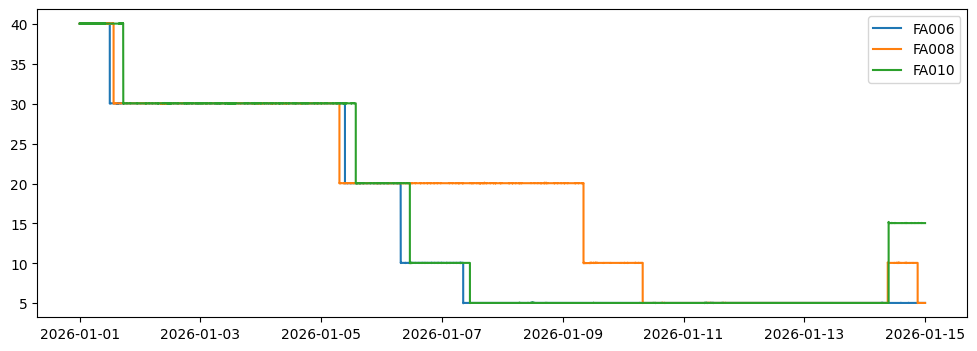

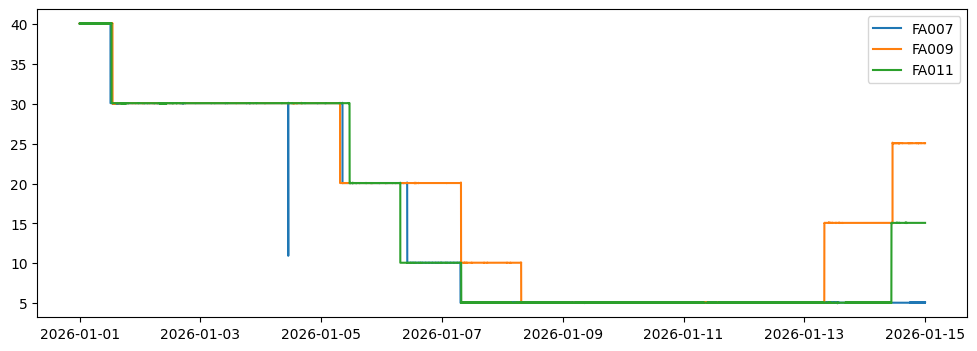

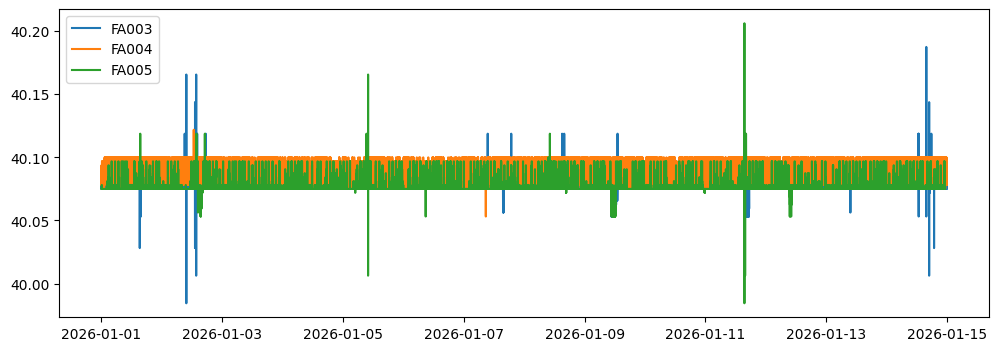

In [34]:
df_analysis = df

plt.figure(figsize = (12, 4))
for batch in ["FA006", "FA008", "FA010"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA007", "FA009", "FA011"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA003", "FA004", "FA005"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

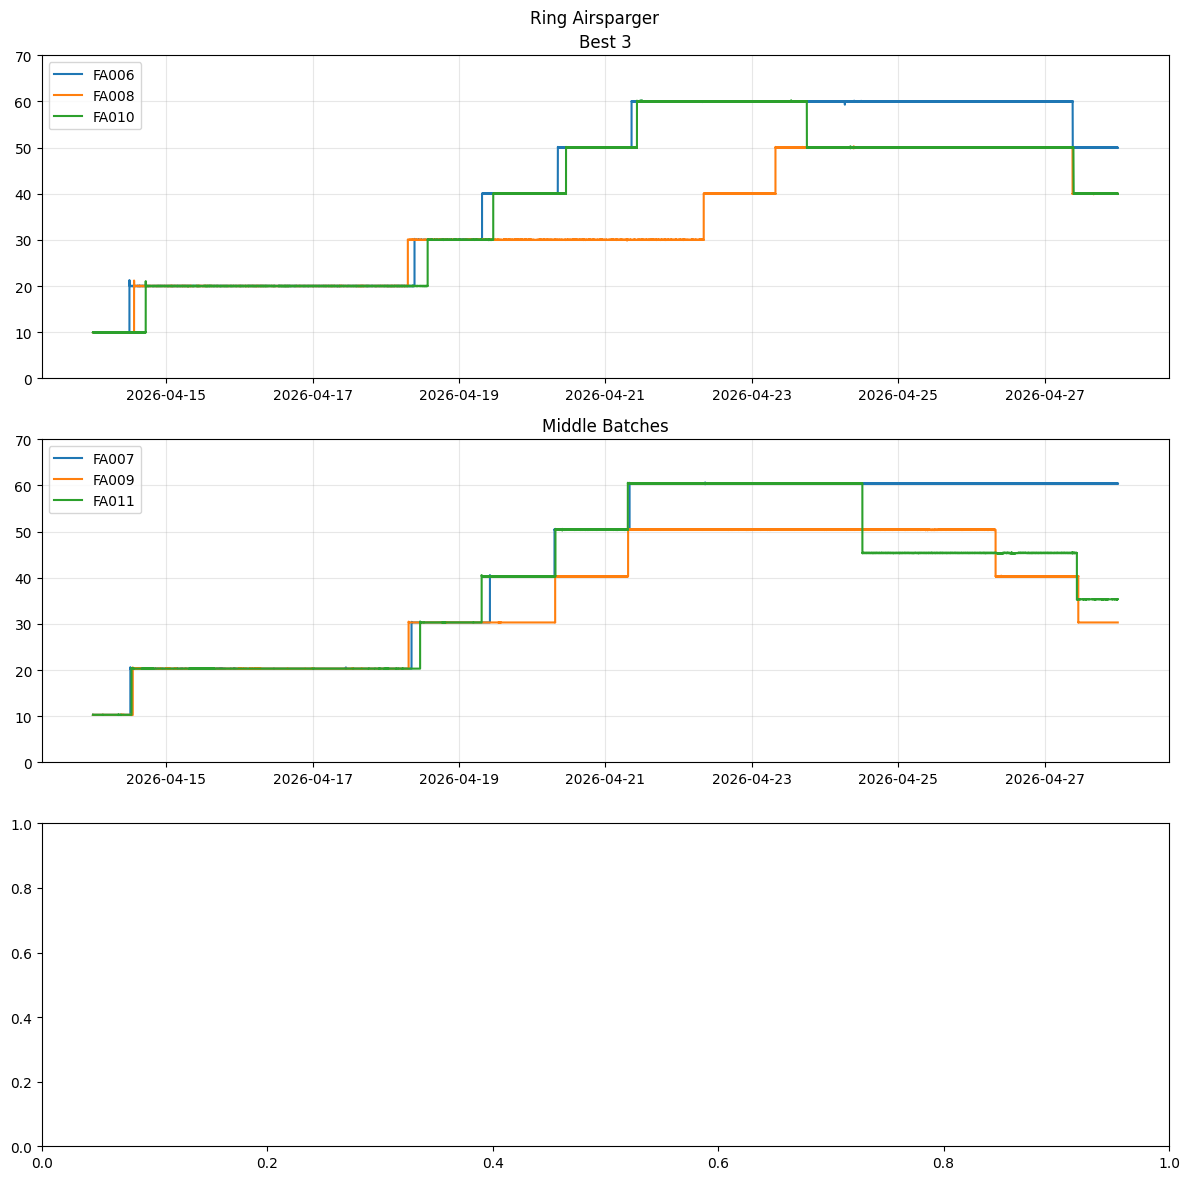

In [35]:
df_analysis = df2

fig, axs = plt.subplots(3, 1, figsize = (12, 12))
ax = axs[0]
for batch in ["FA006", "FA008", "FA010"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    ax.plot(sub_df["timestamp"], sub_df["value"], label = batch)
ax.set_ylim(0, 70)
ax.grid(alpha = 0.3)
ax.legend()
ax.set_title("Best 3")

ax = axs[1]
for batch in ["FA007", "FA009", "FA011"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    ax.plot(sub_df["timestamp"], sub_df["value"], label = batch)
ax.set_ylim(0, 70)
ax.grid(alpha = 0.3)
ax.legend()
ax.set_title("Middle Batches")

# ax = axs[2]
# for batch in ["FA003", "FA004", "FA005"]:
#     sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
#     sub_df = sub_df[sub_df["value"].astype(float) >= 0]
#     sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
#     sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
#     sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
#     sub_df["timestamp"] = pd.to_datetime("00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
#     ax.plot(sub_df["timestamp"], sub_df["value"], label = batch)
# ax.set_ylim(0, 70)
# ax.grid(alpha = 0.3)
# ax.legend()
# ax.set_title("Worst 3")

fig.suptitle("Ring Airsparger")
fig.tight_layout()
fig.show()

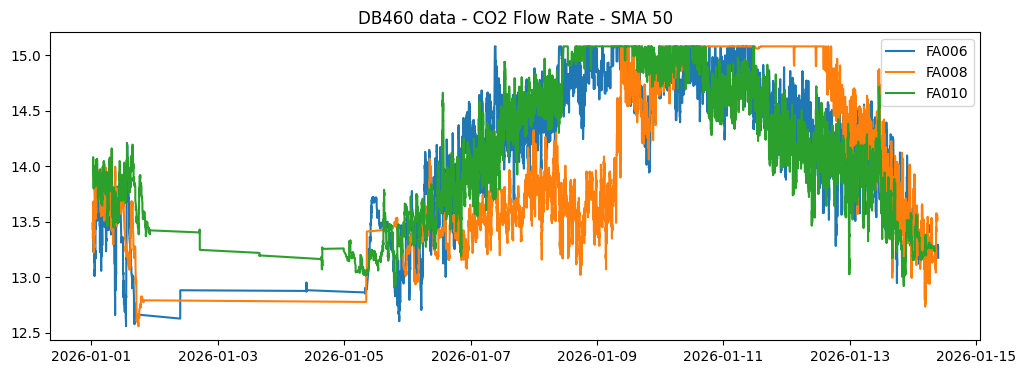

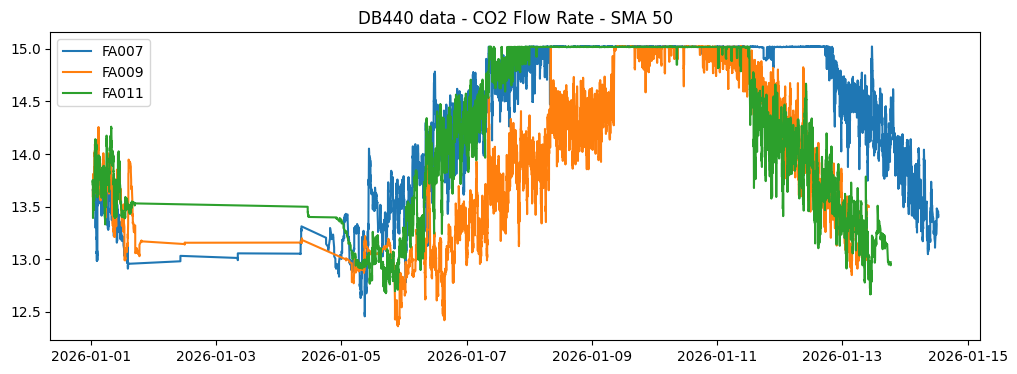

In [32]:
df_analysis = df3

plt.figure(figsize = (12, 4))

colors = ["C0", "C1", "C0"]
for batch_idx, batch in enumerate(["FA006", "FA008", "FA010"]):
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["value"] = sub_df["value"].rolling(window=50).mean()
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.title("DB460 data - CO2 Flow Rate - SMA 50")
plt.legend()

plt.figure(figsize = (12, 4))
colors = ["C1", "C1", "C0"]
for batch_idx, batch in enumerate(["FA007", "FA009", "FA011"]):
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["value"] = sub_df["value"].rolling(window=50).mean()
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.title("DB440 data - CO2 Flow Rate - SMA 50")
plt.legend()

# plt.figure(figsize = (12, 4))
# for batch in ["FA003", "FA004", "FA005"]:
#     sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
#     sub_df = sub_df[sub_df["value"].astype(float) >= 0]
#     sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
#     sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
#     sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
#     sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
#     plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
# plt.legend()

In [14]:
ans = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)[2:].reset_index(drop = True)
ans[ans.columns[-10]].tolist()

[5.19, 4.86, 4.63, 4.62, 3.91, 5.63, 5.79, 5.89, 4.84, 5.56, 5.08]

In [23]:
metadata

NameError: name 'metadata' is not defined

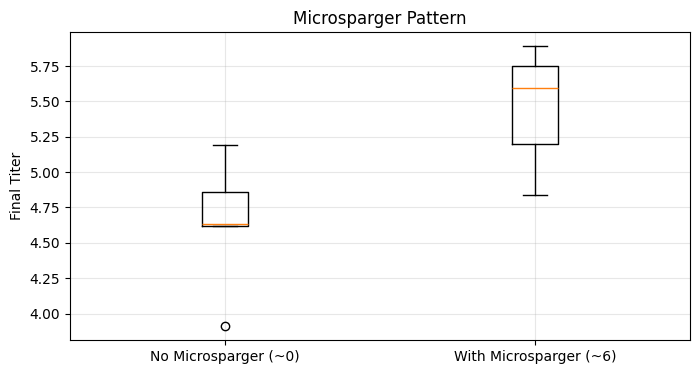

In [16]:
plt.figure(figsize = (8, 4))
plt.boxplot([ans[ans.columns[-10]].tolist()[:5], ans[ans.columns[-10]].tolist()[5:]])
plt.xticks([1, 2], ["No Microsparger (~0)", "With Microsparger (~6)"])
plt.grid(alpha = 0.3)
plt.title("Microsparger Pattern")
plt.ylabel("Final Titer")
plt.show()

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

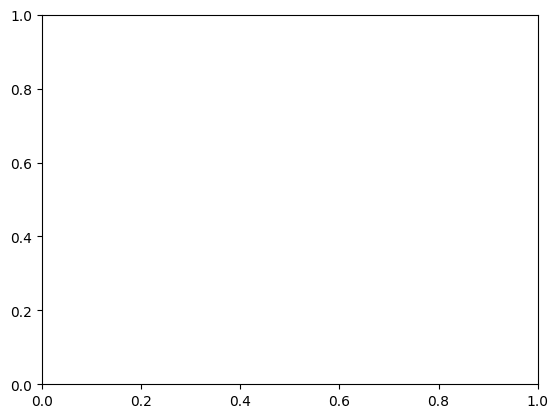

In [17]:
X = df4[["Batch", "value"]].groupby("Batch").mean().reset_index()#["value"].tolist()

plt.boxplot(X['value'] > 0.5, ans[ans.columns[-10]].tolist())

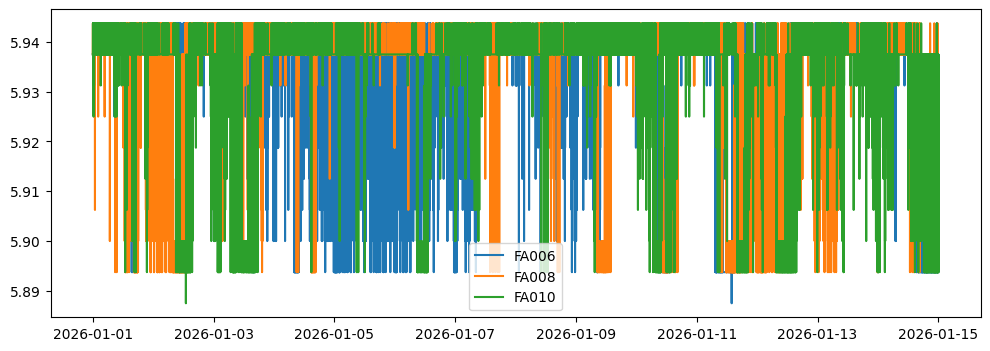

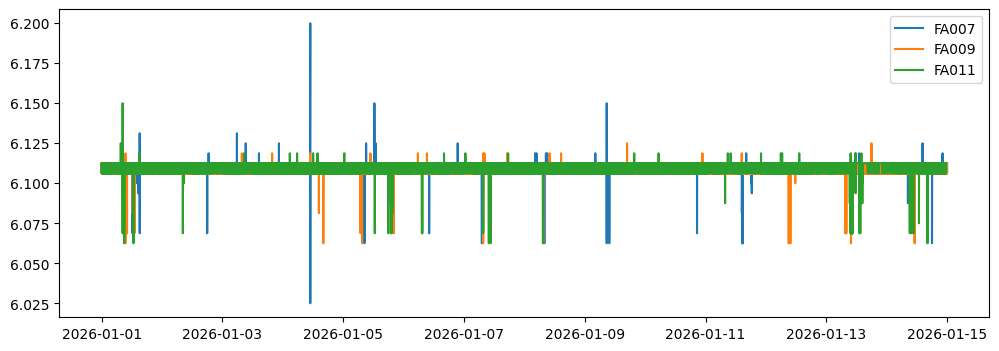

In [33]:
df_analysis = df4

plt.figure(figsize = (12, 4))
for batch in ["FA006", "FA008", "FA010"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA007", "FA009", "FA011"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

# plt.figure(figsize = (12, 4))
# for batch in ["FA003", "FA004", "FA005"]:
#     sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
#     sub_df = sub_df[sub_df["value"].astype(float) >= 0]
#     sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
#     sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
#     sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
#     sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
#     plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
# plt.legend()